# Лабораторная работа №1

## Задание лабораторной

- Сгенерируйте случайный массив в NumPy. Продемонстрируйте на нём различные операции, которые рассматривались на практике <br> (можно взять и другие, тогда будет требование объяснить операцию)
- Возьмите любое изображение из интернета, в котором присутствует хотя бы один объект. Воспользуйтесь функциями из OpenCV для выделения объекта-ов
- Воспроизведите функцию rectangle из OpenCV с нуля. Разрешено использовать только NumPy для разработки из сторонних библиотек <br> (не обязательно, чтобы параметры были те же самые, как в OpenCV, например thickness. Главное, чтобы прямоугольник было видно на изображении). Продемонстрируйте работу вашей функции на тестовом изображении


In [2]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

np.random.seed(42)

---
## Task 1

Создание матрицы

In [3]:

arr = np.random.randint(0, 1000, 20)

print(arr)


[102 435 860 270 106  71 700  20 614 121 466 214 330 458  87 372  99 871
 663 130]


Операции - агрегаты <br>
Min, Max, Mean, Argmin, Argmax

Min - возвращает наименьшее значение <br> Max - возвращает наибольшее значение <br> Mean - возвращает среднее в массиве <br>
Argmin - возвращает индекс минимального значения <br>
Argmax - возвращает индекс максимального значения


In [4]:
print(arr.min(), arr.max(), arr.mean(), sep='\n')
print(f'Min: {arr.argmin()}, Max: {arr.argmax()}')

20
871
349.45
Min: 7, Max: 17


Операции с типом массива: <br>
- Shape - возвращает размер матрицы
- Dtype - возращает тип элементов
- Reshape - изменяет тип матрицы

In [5]:
arr1 = np.random.randint(0, 1000, (4, 6))
print(arr1, end='\n\n')
print(arr1.shape, arr1.dtype, end='\n\n')
arr_new = arr1.reshape(2, 12)
print(arr_new, arr_new.shape)


[[661 308 769 343 491 413]
 [805 385 191 955 276 160]
 [459 313  21 252 747 856]
 [560 474  58 510 681 475]]

(4, 6) int32

[[661 308 769 343 491 413 805 385 191 955 276 160]
 [459 313  21 252 747 856 560 474  58 510 681 475]] (2, 12)


Матричные операции <br>
Операции сложения, умножения, детерминант матрицы

In [6]:
a = np.random.randint(0, 10, (3, 4))
b = np.random.randint(0, 10, (3, 4))
c = np.random.randint(0, 10, (3, 3))

print(a, b, sep='\n\n')

print()
print(f'Det C: {np.linalg.det(c)}')
print(f'Matrix sum: \n {a + b}')
print(f'Matrix multiply: \n {a * b}')
print(f'Matrix product: \n {a @ b.T}')

[[2 6 3 8]
 [2 4 2 6]
 [4 8 6 1]]

[[3 8 1 9]
 [8 9 4 1]
 [3 6 7 2]]

Det C: -154.00000000000006
Matrix sum: 
 [[ 5 14  4 17]
 [10 13  6  7]
 [ 7 14 13  3]]
Matrix multiply: 
 [[ 6 48  3 72]
 [16 36  8  6]
 [12 48 42  2]]
Matrix product: 
 [[129  90  79]
 [ 94  66  56]
 [ 91 129 104]]


Индексация, срезы

In [7]:
array = np.arange(0,100).reshape(10,10)
array

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
       [30, 31, 32, 33, 34, 35, 36, 37, 38, 39],
       [40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
       [50, 51, 52, 53, 54, 55, 56, 57, 58, 59],
       [60, 61, 62, 63, 64, 65, 66, 67, 68, 69],
       [70, 71, 72, 73, 74, 75, 76, 77, 78, 79],
       [80, 81, 82, 83, 84, 85, 86, 87, 88, 89],
       [90, 91, 92, 93, 94, 95, 96, 97, 98, 99]])

In [8]:
print(f'Value at 7 row, 4 column: \n {array[7,4]}', end='\n\n')
print(f'7 row: \n {array[7]}', end='\n\n')
print(f'4 column: \n {array[:,4].reshape(-1,1)}', end='\n\n')
print(f'slice 3-7 rows and 2-5 columns: \n{array[3:8, 2:7]}', end='\n\n')

Value at 7 row, 4 column: 
 74

7 row: 
 [70 71 72 73 74 75 76 77 78 79]

4 column: 
 [[ 4]
 [14]
 [24]
 [34]
 [44]
 [54]
 [64]
 [74]
 [84]
 [94]]

slice 3-7 rows and 2-5 columns: 
[[32 33 34 35 36]
 [42 43 44 45 46]
 [52 53 54 55 56]
 [62 63 64 65 66]
 [72 73 74 75 76]]



----
## Task 2

Далее я буду работать с картинкой ниже: <br><br>
![](./im.jpg)

**Предварительная обработка:** изображение перевожу в градации серого и сглаживаю фильтром Гаусса для подавления шумов.

**Сегментация:** С помощью метода Оцу (автоматический порог) изображение преобразуется в бинарный вид, где объект отделяется от фона.

**Поиск контуров:** Алгоритм находит замкнутые границы объектов на полученной маске.

**Локализация:** Для каждого контура вычисляются координаты описывающего прямоугольника (Bounding Box), который наносится поверх исходного изображения.

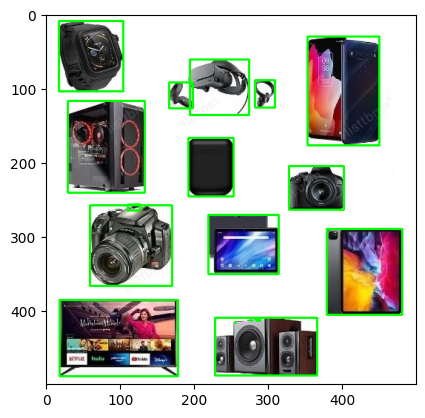

In [9]:
image = cv.imread('im.jpg')
original = image.copy()

gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
blur = cv.GaussianBlur(gray, (5,5), 0)
_, thresh = cv.threshold(blur, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    x, y, w, h = cv.boundingRect(cnt)
    cv.rectangle(original, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.show()

---
## Task 3

In [10]:
def draw_custom_rectangle(img, pt1, pt2, color=(0, 255, 0), thickness=2):
    res = img.copy()
    y1, x1 = pt1
    y2, x2 = pt2
    
    top, bottom = min(y1, y2), max(y1, y2)
    left, right = min(x1, x2), max(x1, x2)
    
    res[top:top + thickness, left:right] = color
    res[bottom - thickness:bottom, left:right] = color
    
    res[top:bottom, left:left + thickness] = color
    res[top:bottom, right - thickness:right] = color
    
    return res

С помощью NumPy я выделил четыре зоны (сверху, снизу, слева и справа), которые соответствуют границам объекта. Используя механизм срезов, перекрасил нужные группы пикселей в целевой цвет (по умолчанию зелёный). Если идти циклами по всем пикселям, то перекрашивание будет происходить в разы дольше.

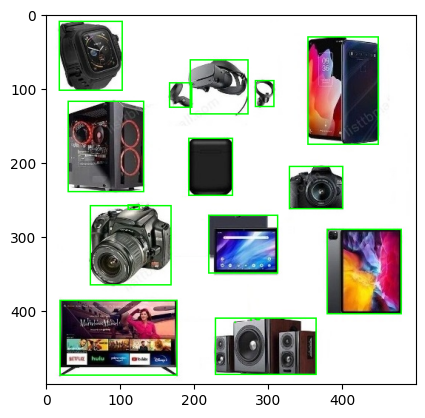

In [14]:
image = cv.imread('im.jpg')
original = image.copy()

gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
blur = cv.GaussianBlur(gray, (5,5), 0)
_, thresh = cv.threshold(blur, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    x, y, w, h = cv.boundingRect(cnt)
    result = draw_custom_rectangle(original, (y, x), (y + h, x + w), thickness=2)
    original = result

plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.show()